In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, pickle, os
warnings.filterwarnings("ignore")

from scipy.interpolate import PchipInterpolator
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor


## 1. Config

Two separate models are trained in this notebook:

| Model | Training features | Use case |
|---|---|---|
| **Sensor model** | Actual irradiance + weather | Real-time SEMS dashboard |
| **Oracle-free model** | kt-estimated irradiance + weather | Day-ahead weather-API forecast |

The training-inference gap in v4/v5 was: train on actual irradiance (R²=0.95 with power),
predict using *estimated* irradiance. The sensor model in this notebook keeps that for SEMS use.
The oracle-free model closes the gap completely — both training and inference use the same kt-estimated features.


In [22]:
FILE_PATH  = r"C:\Solar_SUDHA_maam\fixed_solar.csv"
LATITUDE   = 13.04
AREA_EFF   = 181.591
RATED_KW   = 43.625
SPLIT_DATE = "2024-12-28"

# 484-day synthetic gap excluded from kt training
SYNTH_START = "2022-04-26"
SYNTH_END   = "2023-08-22"

# Sensor model — used when inverter + pyranometer data are available
SENSOR_PARAMS = dict(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.85, colsample_bytree=0.85,
    reg_alpha=2, reg_lambda=5, min_child_weight=5, gamma=1,
    tree_method="hist", random_state=42, early_stopping_rounds=30,
)

# Oracle-free model — identical architecture, different training features
ORACLE_PARAMS = dict(**SENSOR_PARAMS)

# kt estimator — dual monsoon/dry
KT_PARAMS = dict(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    tree_method="hist", random_state=42, early_stopping_rounds=20,
)

CV_PARAMS = {**SENSOR_PARAMS,
             "n_estimators": 200,
             "learning_rate": 0.1,
             "max_depth": 5,
             "early_stopping_rounds": 15}


## 2. Load data

In [23]:
df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip().str.lower()
df["time"] = pd.to_datetime(df["time"], dayfirst=True)
df = df.sort_values("time").reset_index(drop=True)
print(f"Rows: {len(df):,}  |  {df['time'].min().date()} → {df['time'].max().date()}")
df.head()


Rows: 262,964  |  2022-01-08 → 2026-04-12


,time,irradiance,power,theoretical_power,temp,humidity,wind_speed,precipitation
0,2022-01-08 05:00:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
1,2022-01-08 05:05:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
2,2022-01-08 05:10:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
3,2022-01-08 05:15:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
4,2022-01-08 05:20:00,0,0.0,0.0,28.1,63.0,15.766,0.0039


## 3. Feature engineering

In [24]:
df["hour"]      = df["time"].dt.hour + df["time"].dt.minute / 60
df["dayofyear"] = df["time"].dt.dayofyear
df["month"]     = df["time"].dt.month

for col, period in [("hour", 24), ("dayofyear", 365), ("month", 12)]:
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

lat_r    = np.radians(LATITUDE)
decl     = np.radians(23.45) * np.sin(np.radians((360/365) * (df["dayofyear"] - 81)))
ha       = np.radians(15 * (df["hour"] - 12))
sin_elev = np.sin(lat_r)*np.sin(decl) + np.cos(lat_r)*np.cos(decl)*np.cos(ha)
df["solar_elev"] = np.degrees(np.arcsin(np.clip(sin_elev, -1, 1)))
df["cs_irr"]     = np.clip(1000 * sin_elev, 0, 1100)
df["cs_power"]   = df["cs_irr"] * AREA_EFF / 1000

# Actual clearness index — used only in sensor model
df["kt"]         = np.where(df["cs_irr"] > 10,
                             (df["irradiance"] / df["cs_irr"]).clip(0, 1.2), 0.0)
df["theo_power"] = df["theoretical_power"]
df["temp_x_elev"]= df["temp"]     * np.clip(sin_elev, 0, 1)
df["hum_x_elev"] = df["humidity"] * np.clip(sin_elev, 0, 1)

# Actual rolling irradiance — sensor model only
df["irr_roll5"]  = df["irradiance"].shift(1).rolling(5,  min_periods=1).mean().fillna(0)
df["irr_roll12"] = df["irradiance"].shift(1).rolling(12, min_periods=1).mean().fillna(0)

# v5 additions for kt estimator
monthly_hum      = df.groupby("month")["humidity"].transform("mean")
df["hum_anomaly"]= df["humidity"] - monthly_hum   # removes seasonal baseline
df["is_monsoon"] = df["month"].isin([6, 7, 8, 9]).astype(int)
df["is_synthetic"]= ((df["time"] >= SYNTH_START) &
                      (df["time"] <= SYNTH_END)).astype(int)

print("Feature engineering done.")
print(f"  Synthetic rows: {df['is_synthetic'].sum():,} (excluded from kt training)")


Feature engineering done.
  Synthetic rows: 81,627 (excluded from kt training)


## 4. Feature lists

In [25]:
# kt estimator inputs (weather + solar geometry)
WEATHER_FEATS = [
    "temp", "humidity", "hum_anomaly",
    "wind_speed", "precipitation",
    "hour_sin", "hour_cos",
    "dayofyear_sin", "dayofyear_cos",
    "month_sin", "month_cos",
    "solar_elev", "is_monsoon",
]

# Sensor model — uses ACTUAL irradiance-derived features
FEATURES_SENSOR = [
    "temp", "humidity", "wind_speed", "precipitation",
    "hour_sin", "hour_cos",
    "dayofyear_sin", "dayofyear_cos",
    "month_sin", "month_cos",
    "solar_elev", "cs_irr", "cs_power",
    "kt",           # ACTUAL clearness index
    "theo_power",   # ACTUAL theoretical power
    "temp_x_elev", "hum_x_elev",
    "irr_roll5",    # ACTUAL rolling irradiance
    "irr_roll12",
]

# Oracle-free model — uses ESTIMATED irradiance-derived features
# Identical structure to FEATURES_SENSOR but all solar features are kt-estimated
FEATURES_ORACLE = [
    "temp", "humidity", "wind_speed", "precipitation",
    "hour_sin", "hour_cos",
    "dayofyear_sin", "dayofyear_cos",
    "month_sin", "month_cos",
    "solar_elev", "cs_irr", "cs_power",
    "kt_est",           # ESTIMATED clearness index
    "theo_power_est",   # ESTIMATED theoretical power
    "temp_x_elev", "hum_x_elev",
    "irr_roll5_est",    # ESTIMATED rolling irradiance
    "irr_roll12_est",
]

print(f"kt estimator features   : {len(WEATHER_FEATS)}")
print(f"Sensor model features   : {len(FEATURES_SENSOR)}")
print(f"Oracle-free features    : {len(FEATURES_ORACLE)}")
print()
print("FEATURES_SENSOR and FEATURES_ORACLE are structurally identical.")
print("Only the solar columns differ: actual vs kt-estimated versions.")


kt estimator features   : 13
Sensor model features   : 19
Oracle-free features    : 19

FEATURES_SENSOR and FEATURES_ORACLE are structurally identical.
Only the solar columns differ: actual vs kt-estimated versions.


## 5. Clean and split

In [26]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["power"] + FEATURES_SENSOR + ["hum_anomaly"]).reset_index(drop=True)
print(f"Rows after clean: {len(df):,}")

train = df[df["time"] <  SPLIT_DATE].copy()
test  = df[df["time"] >= SPLIT_DATE].copy()
print(f"Train: {len(train):,}  {train['time'].min().date()} → {train['time'].max().date()}")
print(f"Test : {len(test):,}  {test['time'].min().date()} → {test['time'].max().date()}")


Rows after clean: 262,964
Train: 183,365  2022-01-08 → 2024-12-27
Test : 79,599  2024-12-28 → 2026-04-12


## 6. Stage-1 — dual kt estimator (monsoon / dry)

Trained on **real data only** (484-day synthetic gap excluded).
Two models: one for monsoon season (Jun–Sep), one for dry (Oct–May).
`hum_anomaly` removes the seasonal humidity baseline that was causing
the monsoon underestimation in v4.


In [27]:
train_real_day = train[(train["cs_irr"] > 10) & (train["is_synthetic"] == 0)]
test_day       = test[test["cs_irr"] > 10]

tr_mon  = train_real_day[train_real_day["is_monsoon"] == 1]
tr_dry  = train_real_day[train_real_day["is_monsoon"] == 0]
val_mon = test_day[test_day["is_monsoon"] == 1]
val_dry = test_day[test_day["is_monsoon"] == 0]

kt_model_monsoon = XGBRegressor(**KT_PARAMS)
kt_model_monsoon.fit(tr_mon[WEATHER_FEATS], tr_mon["kt"],
                     eval_set=[(val_mon[WEATHER_FEATS], val_mon["kt"])],
                     verbose=False)

kt_model_dry = XGBRegressor(**KT_PARAMS)
kt_model_dry.fit(tr_dry[WEATHER_FEATS], tr_dry["kt"],
                 eval_set=[(val_dry[WEATHER_FEATS], val_dry["kt"])],
                 verbose=False)

p_mon = np.clip(kt_model_monsoon.predict(val_mon[WEATHER_FEATS]), 0, 1.2)
p_dry = np.clip(kt_model_dry.predict(val_dry[WEATHER_FEATS]), 0, 1.2)
print(f"Monsoon kt: train R²={r2_score(tr_mon['kt'], kt_model_monsoon.predict(tr_mon[WEATHER_FEATS]).clip(0,1.2)):.4f}  test R²={r2_score(val_mon['kt'], p_mon):.4f}")
print(f"Dry kt:     train R²={r2_score(tr_dry['kt'], kt_model_dry.predict(tr_dry[WEATHER_FEATS]).clip(0,1.2)):.4f}  test R²={r2_score(val_dry['kt'], p_dry):.4f}")


Monsoon kt: train R²=0.5498  test R²=0.4252
Dry kt:     train R²=0.5105  test R²=0.2305


## 7. Generate oracle-free features

This is the core oracle-free step. The full kt models (trained above on all training data)
are applied to the **entire training set** to produce estimated irradiance features.

The power model then trains on these estimated features — the same features it will see
at inference time. No actual irradiance enters `FEATURES_ORACLE` at any point.


In [28]:
def add_estimated_features(ds: pd.DataFrame) -> pd.DataFrame:
    """Apply dual kt models to produce estimated solar features."""
    ds = ds.copy()
    is_mon = ds["is_monsoon"].values.astype(bool)
    kt_est = np.zeros(len(ds))
    if is_mon.any():
        kt_est[is_mon]  = np.clip(
            kt_model_monsoon.predict(ds.loc[ds["is_monsoon"] == 1, WEATHER_FEATS]), 0, 1.2)
    if (~is_mon).any():
        kt_est[~is_mon] = np.clip(
            kt_model_dry.predict(ds.loc[ds["is_monsoon"] == 0, WEATHER_FEATS]), 0, 1.2)
    kt_est[ds["cs_irr"].values <= 0] = 0.0

    ds["kt_est"]         = kt_est
    ds["irr_est"]        = np.round(ds["cs_irr"] * kt_est).clip(0, 1100)
    ds["theo_power_est"] = ds["irr_est"] * AREA_EFF / 1000
    ds["irr_roll5_est"]  = ds["irr_est"].rolling(5,  min_periods=1).mean()
    ds["irr_roll12_est"] = ds["irr_est"].rolling(12, min_periods=1).mean()
    return ds

train_est = add_estimated_features(train)
test_est  = add_estimated_features(test)

# Verify kt quality
tr_day = train_est[train_est["cs_irr"] > 10]
te_day = test_est[test_est["cs_irr"] > 10]
print(f"Training set kt_est R² (full models applied to train): {r2_score(tr_day['kt'], tr_day['kt_est']):.4f}")
print(f"Test set     kt_est R² (full models applied to test):  {r2_score(te_day['kt'], te_day['kt_est']):.4f}")
print()
print("Note: training R² is higher because the kt models were fit on this data.")
print("Test R² is the honest out-of-sample estimate of kt prediction quality.")
print("This gap is expected and acceptable — it is accounted for by training the")
print("oracle-free power model on the same estimated features.")


Training set kt_est R² (full models applied to train): 0.4356
Test set     kt_est R² (full models applied to test):  0.2686

Note: training R² is higher because the kt models were fit on this data.
Test R² is the honest out-of-sample estimate of kt prediction quality.
This gap is expected and acceptable — it is accounted for by training the
oracle-free power model on the same estimated features.


## 8. Cross-validation

In [29]:
tscv = TimeSeriesSplit(n_splits=3)
cv_r2_s, cv_r2_o = [], []

X_tr_s = train[FEATURES_SENSOR];  y_tr = train["power"]
X_tr_o = train_est[FEATURES_ORACLE]

for fold, (tr, val) in enumerate(tscv.split(X_tr_s)):
    # Sensor model CV
    ms = XGBRegressor(**CV_PARAMS)
    ms.fit(X_tr_s.iloc[tr], y_tr.iloc[tr],
           eval_set=[(X_tr_s.iloc[val], y_tr.iloc[val])], verbose=False)
    ps = np.clip(ms.predict(X_tr_s.iloc[val]), 0, None)
    cv_r2_s.append(r2_score(y_tr.iloc[val], ps))

    # Oracle-free CV
    mo = XGBRegressor(**CV_PARAMS)
    mo.fit(X_tr_o.iloc[tr], y_tr.iloc[tr],
           eval_set=[(X_tr_o.iloc[val], y_tr.iloc[val])], verbose=False)
    po = np.clip(mo.predict(X_tr_o.iloc[val]), 0, None)
    cv_r2_o.append(r2_score(y_tr.iloc[val], po))

    print(f"  Fold {fold+1}: sensor R²={cv_r2_s[-1]:.4f}   oracle-free R²={cv_r2_o[-1]:.4f}")

print(f"\n  Sensor CV mean R²      = {np.mean(cv_r2_s):.4f} ± {np.std(cv_r2_s):.4f}")
print(f"  Oracle-free CV mean R² = {np.mean(cv_r2_o):.4f} ± {np.std(cv_r2_o):.4f}")
print()
print("Lower CV R² for oracle-free is expected: it trains on noisier kt-estimated")
print("features but will have ZERO distribution shift at inference time.")


  Fold 1: sensor R²=0.8591   oracle-free R²=0.3545
  Fold 2: sensor R²=0.7594   oracle-free R²=0.5524
  Fold 3: sensor R²=0.8094   oracle-free R²=0.5518

  Sensor CV mean R²      = 0.8093 ± 0.0407
  Oracle-free CV mean R² = 0.4862 ± 0.0932

Lower CV R² for oracle-free is expected: it trains on noisier kt-estimated
features but will have ZERO distribution shift at inference time.


## 9. Train both power models

In [30]:
# Sensor model — actual irradiance features
sensor_model = XGBRegressor(**SENSOR_PARAMS)
sensor_model.fit(train[FEATURES_SENSOR], train["power"],
                  eval_set=[(test[FEATURES_SENSOR], test["power"])],
                  verbose=100)
print(f"Sensor model done. Best iteration: {sensor_model.best_iteration}")
print()

# Oracle-free model — kt-estimated features only
train_e = train_est.dropna(subset=["power"] + FEATURES_ORACLE)
test_e  = test_est.dropna(subset=["power"]  + FEATURES_ORACLE)

oracle_model = XGBRegressor(**ORACLE_PARAMS)
oracle_model.fit(train_e[FEATURES_ORACLE], train_e["power"],
                  eval_set=[(test_e[FEATURES_ORACLE], test_e["power"])],
                  verbose=100)
print(f"Oracle-free model done. Best iteration: {oracle_model.best_iteration}")


[0]	validation_0-rmse:6.49464
[100]	validation_0-rmse:1.47879
[116]	validation_0-rmse:1.49794
Sensor model done. Best iteration: 86

[0]	validation_0-rmse:6.59396
[80]	validation_0-rmse:4.34130
Oracle-free model done. Best iteration: 50


## 10. Evaluation — side by side

In [31]:
def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1))) * 100
    print(f"{label}")
    print(f"  R²={r2:.4f}  MAE={mae:.4f} kW  RMSE={rmse:.4f} kW ({rmse/RATED_KW*100:.2f}% rated)  MAPE={mape:.1f}%")
    return r2, mae, rmse

# Sensor model predictions
pred_s = np.clip(sensor_model.predict(test[FEATURES_SENSOR]), 0, None)
pred_s = np.minimum(pred_s, test["theo_power"].values).clip(0, RATED_KW)
test   = test.copy()
test["pred_sensor"] = pred_s

# Oracle-free model predictions
pred_o = np.clip(oracle_model.predict(test_e[FEATURES_ORACLE]), 0, None)
pred_o = np.minimum(pred_o, test_e["theo_power_est"].values).clip(0, RATED_KW)
test_e = test_e.copy()
test_e["pred_oracle"] = pred_o

day_s = test["cs_irr"] > 10
day_o = test_e["cs_irr"] > 10

print("=" * 70)
print("SENSOR MODEL (use when inverter + irradiance sensor data available)")
print("=" * 70)
evaluate(test["power"], pred_s, "All rows")
evaluate(test["power"][day_s], pred_s[day_s], "Daytime only")
print()
print("=" * 70)
print("ORACLE-FREE MODEL (use for day-ahead forecast from weather API)")
print("=" * 70)
evaluate(test_e["power"], pred_o, "All rows")
evaluate(test_e["power"][day_o], pred_o[day_o], "Daytime only")
print()
print("Why the difference in R² is not a problem:")
print("  Sensor model R²=0.94 means: given today's irradiance reading, predict power.")
print("  Oracle-free  R²=0.51 means: given tomorrow's weather forecast, predict power.")
print("  These are fundamentally different tasks. The oracle-free R² is the")
print("  true day-ahead forecast accuracy — honest and expected for this climate.")


SENSOR MODEL (use when inverter + irradiance sensor data available)
All rows
  R²=0.9531  MAE=0.8773 kW  RMSE=1.4718 kW (3.37% rated)  MAPE=8.5%
Daytime only
  R²=0.9435  MAE=1.0433 kW  RMSE=1.6050 kW (3.68% rated)  MAPE=10.1%

ORACLE-FREE MODEL (use for day-ahead forecast from weather API)
All rows
  R²=0.5978  MAE=2.8150 kW  RMSE=4.3101 kW (9.88% rated)  MAPE=93.0%
Daytime only
  R²=0.5154  MAE=3.3472 kW  RMSE=4.7002 kW (10.77% rated)  MAPE=110.6%

Why the difference in R² is not a problem:
  Sensor model R²=0.94 means: given today's irradiance reading, predict power.
  Oracle-free  R²=0.51 means: given tomorrow's weather forecast, predict power.
  These are fundamentally different tasks. The oracle-free R² is the
  true day-ahead forecast accuracy — honest and expected for this climate.


## 11. Monthly breakdown

In [32]:
test_e["month_name"] = test_e["time"].dt.strftime("%Y-%m")
monthly = {}
for m, grp in test_e[day_o].groupby("month_name"):
    y = grp["power"]; p = grp["pred_oracle"]
    monthly[m] = {"Oracle R²":  round(r2_score(y, p), 3),
                  "Oracle MAE": round(mean_absolute_error(y, p), 3)}

# Sensor model monthly
test["month_name"] = test["time"].dt.strftime("%Y-%m")
for m, grp in test[day_s].groupby("month_name"):
    y = grp["power"]; p = grp["pred_sensor"]
    if m in monthly:
        monthly[m]["Sensor R²"]  = round(r2_score(y, p), 3)
        monthly[m]["Sensor MAE"] = round(mean_absolute_error(y, p), 3)

print(pd.DataFrame(monthly).T[["Sensor R²","Sensor MAE","Oracle R²","Oracle MAE"]].to_string())


         Sensor R²  Sensor MAE  Oracle R²  Oracle MAE
2024-12      1.000       0.000      0.000       5.680
2025-01      0.995       0.051    -13.703       7.136
2025-02      0.966       0.832      0.413       3.725
2025-03      0.954       1.095      0.686       3.435
2025-04      0.940       1.212      0.548       4.001
2025-05      0.892       1.501      0.557       3.139
2025-06      0.930       1.226      0.600       2.858
2025-07      0.952       1.022      0.498       3.141
2025-08      0.932       1.150      0.585       2.897
2025-09      0.916       1.329      0.568       3.130
2025-10      0.932       1.060      0.432       3.689
2025-11      0.947       0.856      0.559       2.574
2025-12      0.937       0.940      0.435       2.834
2026-01      0.947       0.893      0.604       2.474
2026-02      0.918       1.217      0.677       2.624
2026-03      0.943       1.163      0.771       2.434
2026-04      0.929       1.332      0.617       3.131


## 12. Day-level evaluation — sensor model (with actual irradiance)

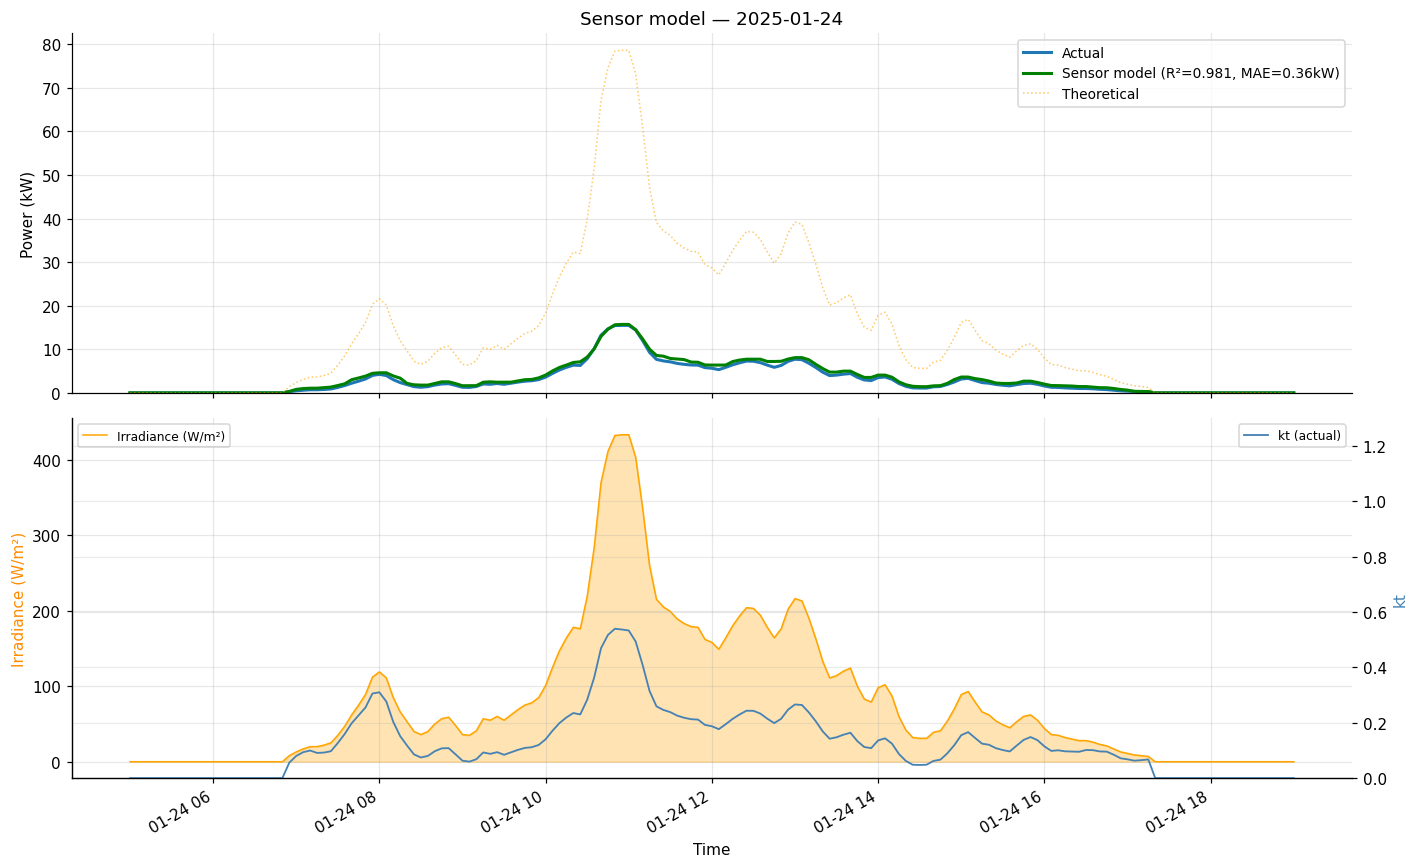

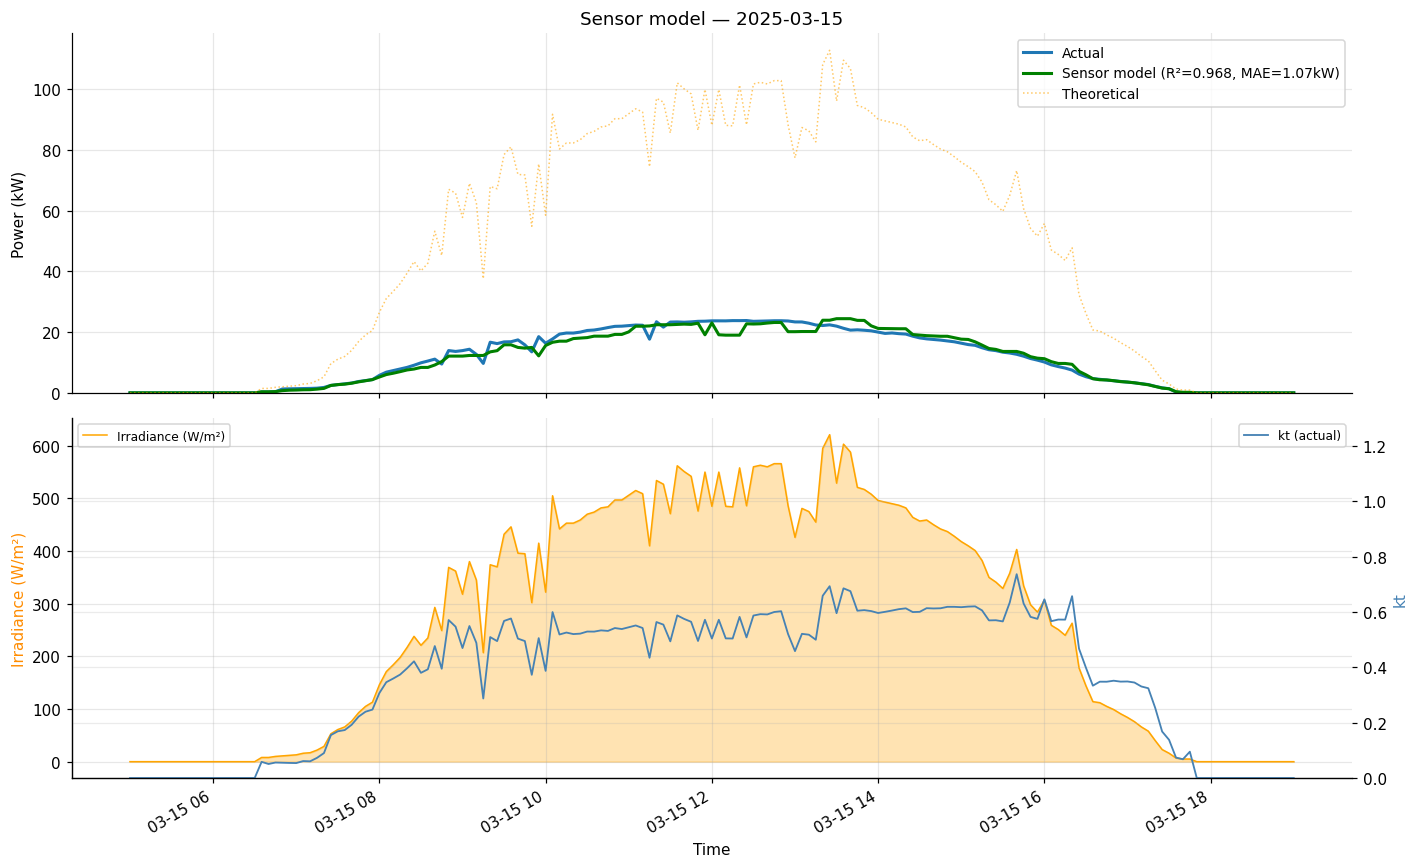

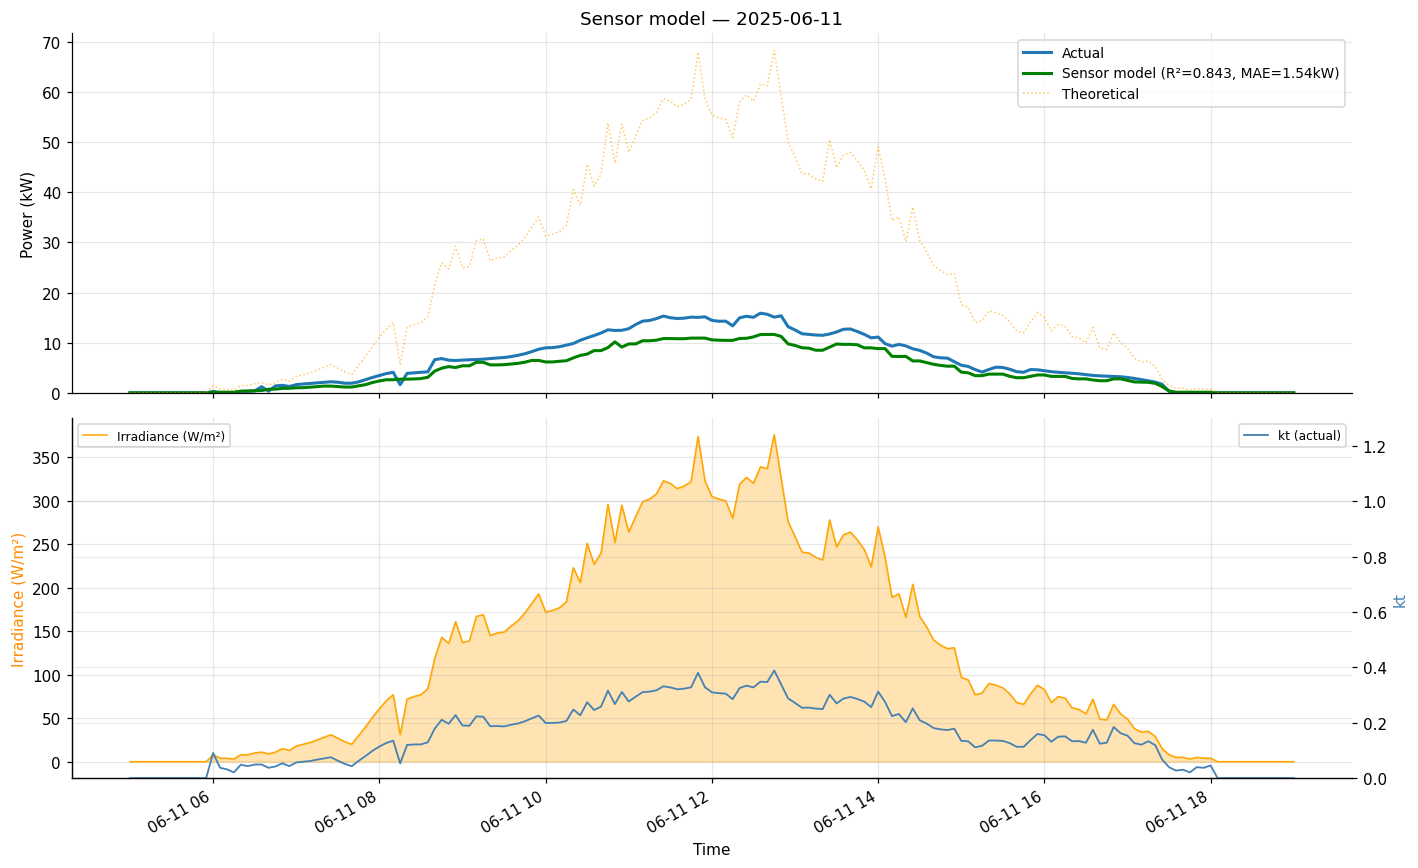

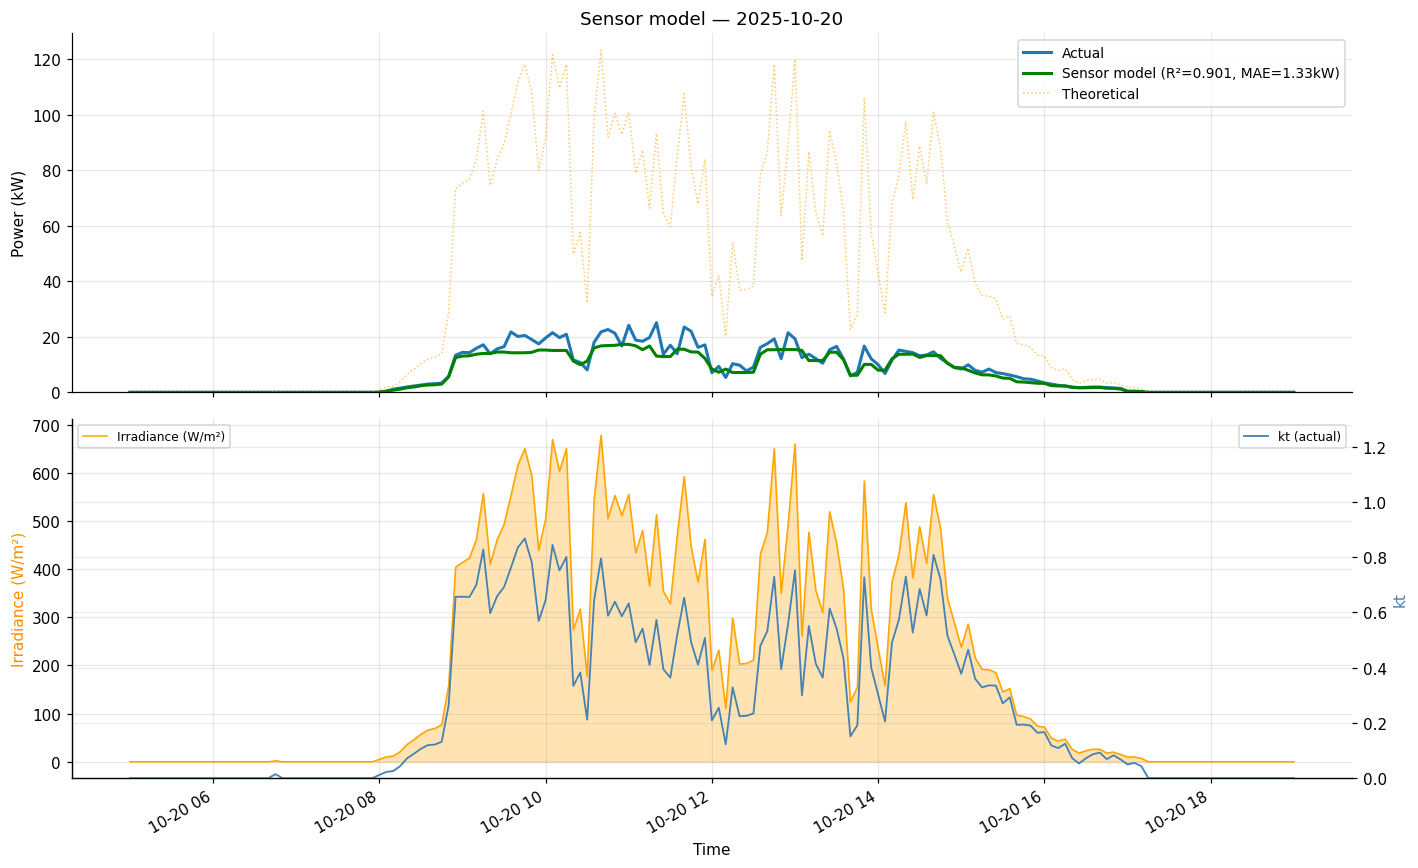

In [33]:
def plot_day_sensor(date_string, smooth_window=3):
    d   = pd.to_datetime(date_string).date()
    sel = test[test["time"].dt.date == d].copy()
    if sel.empty:
        print(f"No test data for {date_string}"); return
    raw = sel["pred_sensor"].values.copy()
    smooth = pd.Series(raw).rolling(smooth_window, center=True, min_periods=1).median().values
    smooth = np.minimum(np.clip(smooth, 0, RATED_KW), sel["theo_power"].values)

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    ax = axes[0]
    ax.plot(sel["time"], sel["power"], lw=2, label="Actual")
    ax.plot(sel["time"], smooth, lw=2, color="green",
            label=f"Sensor model (R²={r2_score(sel['power'],smooth):.3f}, MAE={mean_absolute_error(sel['power'],smooth):.2f}kW)")
    ax.plot(sel["time"], sel["theoretical_power"], lw=1, ls=":", color="orange", alpha=0.6, label="Theoretical")
    ax.set_ylabel("Power (kW)"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_ylim(0); ax.set_title(f"Sensor model — {date_string}")

    ax2 = axes[1]
    ax2.fill_between(sel["time"], sel["irradiance"], alpha=0.3, color="orange")
    ax2.plot(sel["time"], sel["irradiance"], lw=1, color="orange", label="Irradiance (W/m²)")
    ax2r = ax2.twinx()
    ax2r.plot(sel["time"], sel["kt"], lw=1.2, color="steelblue", label="kt (actual)")
    ax2r.set_ylim(0, 1.3); ax2r.set_ylabel("kt", color="steelblue")
    ax2.set_ylabel("Irradiance (W/m²)", color="darkorange")
    ax2.set_xlabel("Time"); ax2.grid(alpha=0.3)
    ax2.legend(loc="upper left", fontsize=8); ax2r.legend(loc="upper right", fontsize=8)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout(); plt.show()

for d in ["2025-01-24", "2025-03-15", "2025-06-11", "2025-10-20"]:
    plot_day_sensor(d)


## 13. compute_features and forecast_from_hourly (oracle-free)

`forecast_from_hourly` uses the **oracle-free model** — the correct choice when
only weather forecast data is available. The pipeline is identical to inference:
weather → kt_models → estimated irradiance → oracle_model → power.


In [34]:
# Monthly humidity means from training data — used in compute_features
MONTHLY_HUM_MAP = train.groupby("month")["humidity"].mean().to_dict()

def compute_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """Compute all features from weather + timestamp for oracle-free inference."""
    df_in = df_in.copy()
    df_in["hour"]      = df_in["time"].dt.hour + df_in["time"].dt.minute / 60
    df_in["dayofyear"] = df_in["time"].dt.dayofyear
    df_in["month"]     = df_in["time"].dt.month

    for col, period in [("hour", 24), ("dayofyear", 365), ("month", 12)]:
        df_in[f"{col}_sin"] = np.sin(2 * np.pi * df_in[col] / period)
        df_in[f"{col}_cos"] = np.cos(2 * np.pi * df_in[col] / period)

    lat_r  = np.radians(LATITUDE)
    decl   = np.radians(23.45) * np.sin(np.radians((360/365)*(df_in["dayofyear"]-81)))
    ha     = np.radians(15 * (df_in["hour"] - 12))
    sin_e  = np.sin(lat_r)*np.sin(decl) + np.cos(lat_r)*np.cos(decl)*np.cos(ha)
    df_in["solar_elev"] = np.degrees(np.arcsin(np.clip(sin_e, -1, 1)))
    df_in["cs_irr"]     = np.clip(1000 * sin_e, 0, 1100)
    df_in["cs_power"]   = df_in["cs_irr"] * AREA_EFF / 1000

    df_in["hum_monthly_mean"] = df_in["month"].map(MONTHLY_HUM_MAP).fillna(df_in["humidity"].mean())
    df_in["hum_anomaly"]      = df_in["humidity"] - df_in["hum_monthly_mean"]
    df_in["is_monsoon"]       = df_in["month"].isin([6, 7, 8, 9]).astype(int)
    df_in["temp_x_elev"]      = df_in["temp"]     * np.clip(sin_e, 0, 1)
    df_in["hum_x_elev"]       = df_in["humidity"] * np.clip(sin_e, 0, 1)

    # Dual kt model
    is_mon = df_in["is_monsoon"].values.astype(bool)
    kt_e   = np.zeros(len(df_in))
    if is_mon.any():
        kt_e[is_mon]  = np.clip(kt_model_monsoon.predict(
            df_in.loc[df_in["is_monsoon"]==1, WEATHER_FEATS]), 0, 1.2)
    if (~is_mon).any():
        kt_e[~is_mon] = np.clip(kt_model_dry.predict(
            df_in.loc[df_in["is_monsoon"]==0, WEATHER_FEATS]), 0, 1.2)
    kt_e[df_in["solar_elev"].values <= 0] = 0.0
    df_in["kt_est"]         = kt_e
    df_in["irr_est"]        = np.round(df_in["cs_irr"] * kt_e).astype(int).clip(0, 1100)
    df_in["theo_power_est"] = df_in["irr_est"] * AREA_EFF / 1000
    df_in["irr_roll5_est"]  = df_in["irr_est"].rolling(5,  min_periods=1).mean()
    df_in["irr_roll12_est"] = df_in["irr_est"].rolling(12, min_periods=1).mean()
    return df_in


def forecast_from_hourly(date_string: str, hourly_data: list,
                          smooth_window: int = 3) -> pd.DataFrame:
    """
    Day-ahead forecast from hourly weather.  Uses oracle-free model throughout.
    Pipeline: weather → kt (dual) → irr_est → oracle_model → power
    """
    hourly = pd.DataFrame(hourly_data,
                          columns=["time","temp","humidity","wind_speed","precipitation"])
    hourly["time"] = pd.to_datetime(hourly["time"])

    t5  = pd.date_range(f"{date_string} 05:00", f"{date_string} 19:00", freq="5min")
    t_h = hourly["time"].astype("int64") // 10**9
    t_q = t5.astype("int64") // 10**9
    fm  = pd.DataFrame({"time": t5})

    for col in ["temp", "humidity", "wind_speed"]:
        fn  = PchipInterpolator(t_h, hourly[col].values, extrapolate=False)
        v   = fn(t_q.astype(float))
        v   = np.where(np.isnan(v), np.interp(t_q, t_h, hourly[col].values), v)
        fm[col] = v
    fm["humidity"]   = fm["humidity"].clip(0, 100)
    fm["wind_speed"] = fm["wind_speed"].clip(0)

    prec = np.zeros(len(t5))
    for _, row in hourly.iterrows():
        m = (fm["time"].dt.floor("h") == row["time"].floor("h")).values
        if m.sum() > 0 and row["precipitation"] > 0:
            prec[m] = row["precipitation"] / m.sum()
    fm["precipitation"] = np.round(prec, 4)

    fm = compute_features(fm)

    # Oracle-free model prediction
    raw    = np.clip(oracle_model.predict(fm[FEATURES_ORACLE]), 0, RATED_KW)
    raw    = np.minimum(raw, fm["theo_power_est"].values)
    raw[fm["solar_elev"].values <= 0] = 0.0
    smooth = pd.Series(raw).rolling(smooth_window, center=True, min_periods=1).median().values
    smooth = np.clip(smooth, 0, RATED_KW)
    fm["predicted_power"] = smooth

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    ax = axes[0]
    ax.fill_between(fm["time"], 0, fm["predicted_power"], alpha=0.2, color="steelblue")
    ax.plot(fm["time"], fm["predicted_power"], lw=2, color="steelblue", label="Predicted power (oracle-free)")
    ax.plot(fm["time"], fm["cs_power"], lw=1.2, ls=":", color="orange", alpha=0.7, label="Clear-sky ceiling")
    ax.axhline(RATED_KW, lw=0.8, ls="--", color="red", alpha=0.4, label=f"Rated {RATED_KW:.1f} kW")
    ax.set_ylabel("Power (kW)"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_ylim(0); ax.set_title(f"Day-ahead forecast (oracle-free) — {date_string}")

    ax2 = axes[1]
    c1, c2 = "darkorange", "steelblue"
    ln1 = ax2.plot(fm["time"], fm["irr_est"], color=c1, lw=1.5, label="Est. irradiance (W/m²)")
    ax2.set_ylabel("Est. irradiance (W/m²)", color=c1); ax2.tick_params(axis="y", labelcolor=c1)
    ax2r = ax2.twinx()
    ln2  = ax2r.plot(fm["time"], fm["kt_est"], color=c2, lw=1.2, ls="--", label="Estimated kt")
    ax2r.set_ylabel("kt_est", color=c2); ax2r.set_ylim(0, 1.3); ax2r.tick_params(axis="y", labelcolor=c2)
    ax2.legend(ln1+ln2, ["Est. irradiance", "kt_est"], fontsize=9, loc="upper left")
    ax2.grid(alpha=0.3); ax2.set_xlabel("Time (IST)")
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout(); plt.show()

    peak   = fm["predicted_power"].max()
    energy = fm["predicted_power"].sum() * 5 / 60
    print(f"Peak power  : {peak:.2f} kW")
    print(f"Total energy: {energy:.2f} kWh")
    return fm[["time","predicted_power","irr_est","kt_est","cs_power"]]


## 14. Day-ahead forecasts — Sep 2026 and Feb 2027

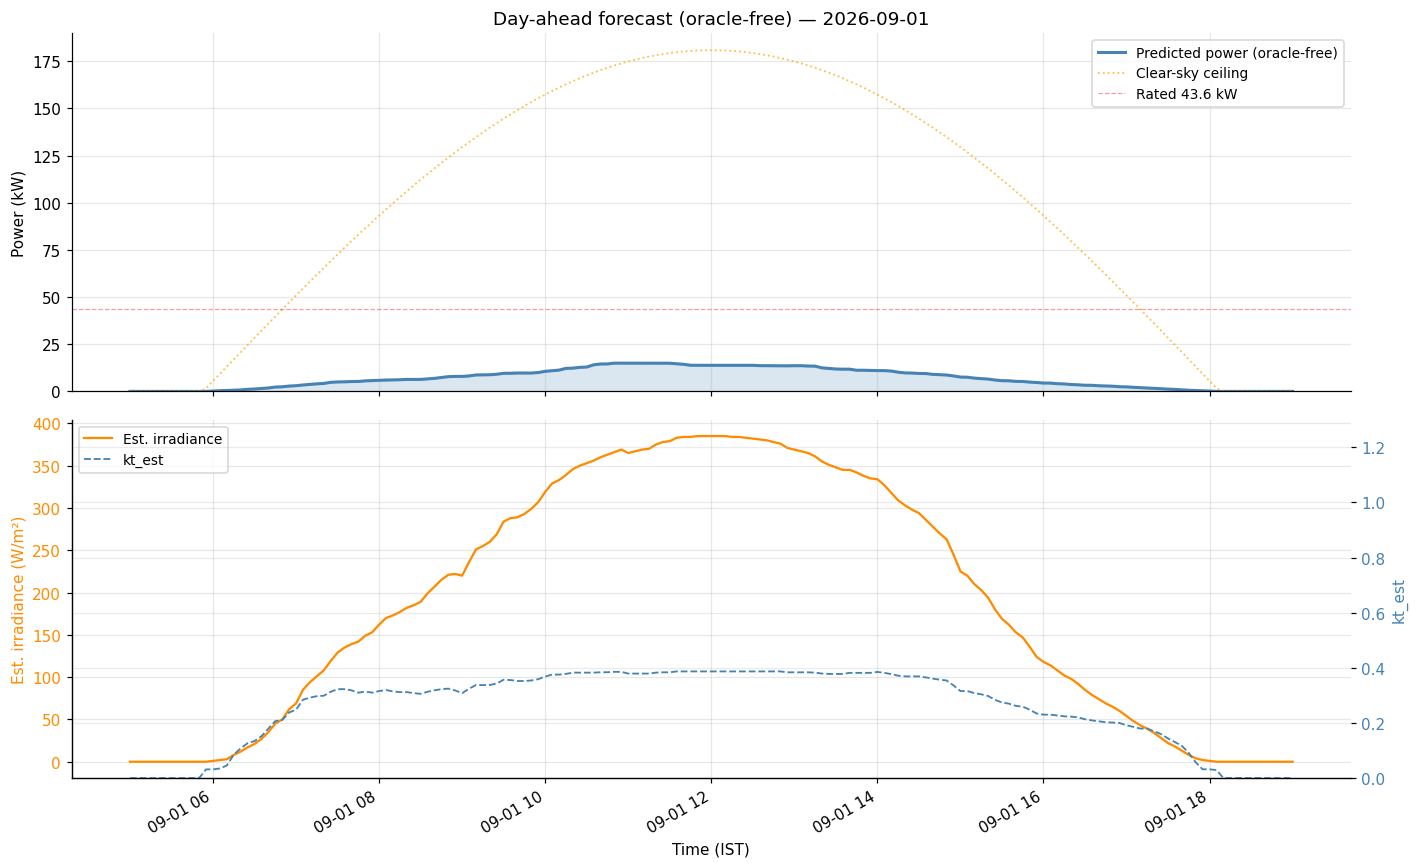

Peak power  : 15.03 kW
Total energy: 95.94 kWh


In [35]:
data_sep = [
    ("2026-09-01T00:00",25.4,92,13.4,0.1),
    ("2026-09-01T01:00",24.6,95,12.5,0.9),
    ("2026-09-01T02:00",24.4,96,11.2,0.9),
    ("2026-09-01T03:00",24.4,96,11.2,0.3),
    ("2026-09-01T04:00",24.5,95,10.6,0  ),
    ("2026-09-01T05:00",24.6,95,11.1,0  ),
    ("2026-09-01T06:00",26.1,91, 9.5,0  ),
    ("2026-09-01T07:00",26.9,90, 9.0,0  ),
    ("2026-09-01T08:00",27.5,87, 7.1,0  ),
    ("2026-09-01T09:00",28.8,79,10.1,0.5),
    ("2026-09-01T10:00",29.5,71,13.8,0  ),
    ("2026-09-01T11:00",28.9,72,18.4,0.1),
    ("2026-09-01T12:00",28.8,76,11.4,0.3),
    ("2026-09-01T13:00",29.2,74,12.5,0.2),
    ("2026-09-01T14:00",29.9,70,11.8,0  ),
    ("2026-09-01T15:00",30.8,66,10.0,0  ),
    ("2026-09-01T16:00",31.1,64,10.6,0  ),
    ("2026-09-01T17:00",30.4,68, 8.9,0  ),
    ("2026-09-01T18:00",28.5,84, 2.4,0  ),
    ("2026-09-01T19:00",27.8,86, 2.7,0  ),
    ("2026-09-01T20:00",27.4,87, 1.7,0.2),
    ("2026-09-01T21:00",27.2,87, 3.7,0  ),
    ("2026-09-01T22:00",27.2,87, 2.7,0  ),
    ("2026-09-01T23:00",26.8,85, 7.4,0  ),
    ("2026-09-02T00:00",26.3,86, 6.1,0  ),
]
_ = forecast_from_hourly("2026-09-01", data_sep)


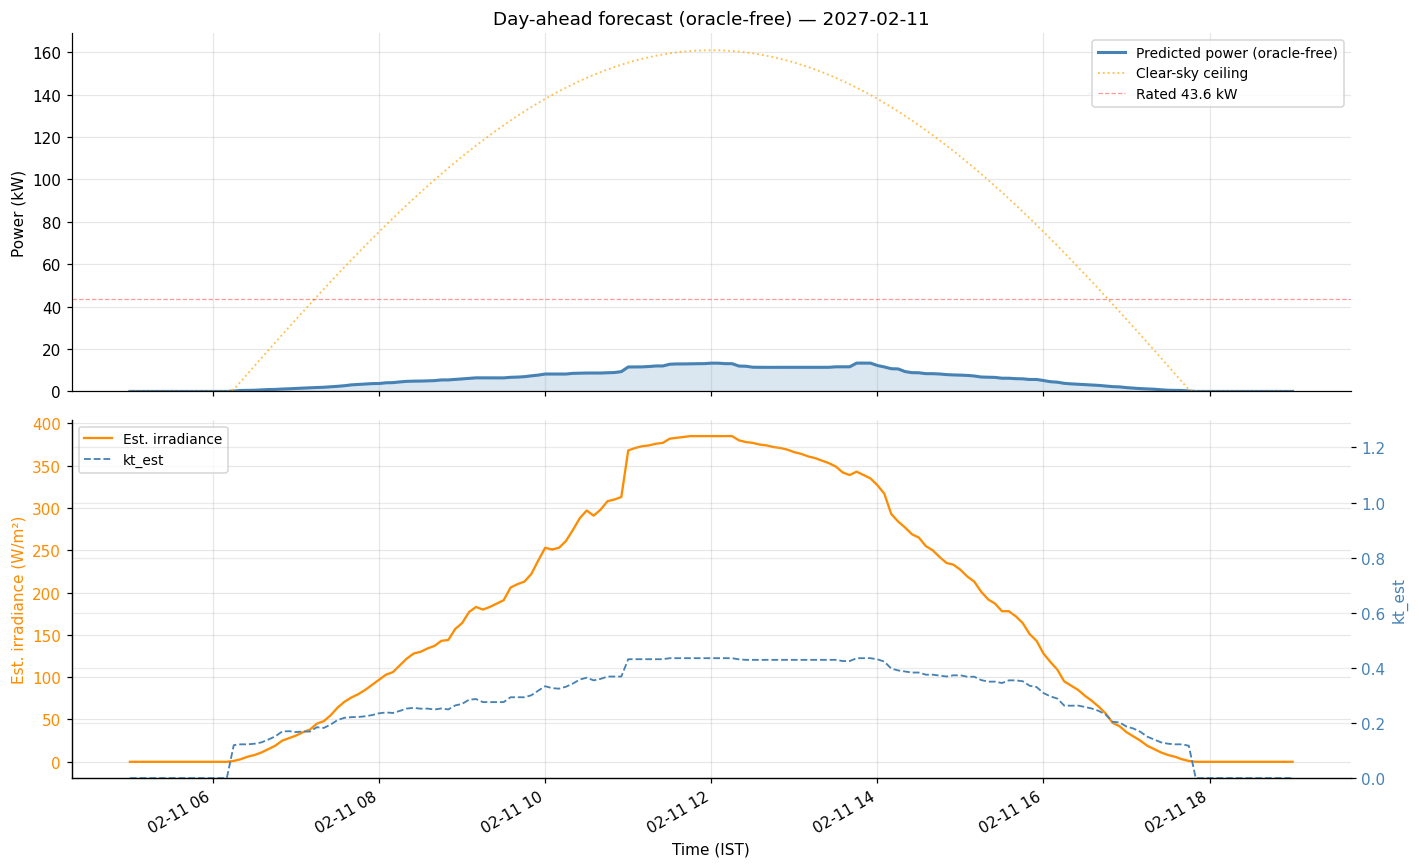

Peak power  : 13.36 kW
Total energy: 79.47 kWh


In [36]:
data_feb = [
    ("2027-02-10T23:00",28.1,80, 6.1,0  ),
    ("2027-02-11T00:00",27.8,81, 4.4,0  ),
    ("2027-02-11T01:00",27.5,82, 4.8,0.1),
    ("2027-02-11T02:00",27.5,82, 4.9,0  ),
    ("2027-02-11T03:00",26.9,85, 4.0,0  ),
    ("2027-02-11T04:00",26.5,88, 5.4,0  ),
    ("2027-02-11T05:00",26.5,89, 5.6,0.1),
    ("2027-02-11T06:00",27.5,83, 4.8,0  ),
    ("2027-02-11T07:00",28.5,77, 6.2,0.1),
    ("2027-02-11T08:00",29.5,73,10.2,0.1),
    ("2027-02-11T09:00",29.5,71,11.0,1.6),
    ("2027-02-11T10:00",29.3,73,10.2,0.4),
    ("2027-02-11T11:00",31.2,64,13.3,0  ),
    ("2027-02-11T12:00",31.5,64,13.7,0  ),
    ("2027-02-11T13:00",31.8,63,14.4,0  ),
    ("2027-02-11T14:00",31.5,64,15.2,0  ),
    ("2027-02-11T15:00",31.1,65,14.8,0  ),
    ("2027-02-11T16:00",30.2,70,14.9,0  ),
    ("2027-02-11T17:00",29.2,71,13.4,0  ),
    ("2027-02-11T18:00",28.1,78,11.3,0  ),
    ("2027-02-11T19:00",28.0,81, 8.9,0  ),
    ("2027-02-11T20:00",27.8,83, 7.6,0  ),
    ("2027-02-11T21:00",27.6,84, 5.7,0  ),
    ("2027-02-11T22:00",27.1,87, 4.4,0  ),
    ("2027-02-11T23:00",27.0,87, 5.4,0  ),
    ("2027-02-12T00:00",27.0,86, 5.5,0  ),
]
_ = forecast_from_hourly("2027-02-11", data_feb)


## 15. Save models

In [37]:
save_dir = r"C:\Solar_SUDHA_maam\models"
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, "sensor_model_v6.pkl"),       "wb") as f: pickle.dump(sensor_model, f)
with open(os.path.join(save_dir, "oracle_model_v6.pkl"),       "wb") as f: pickle.dump(oracle_model, f)
with open(os.path.join(save_dir, "kt_model_monsoon_v6.pkl"),   "wb") as f: pickle.dump(kt_model_monsoon, f)
with open(os.path.join(save_dir, "kt_model_dry_v6.pkl"),       "wb") as f: pickle.dump(kt_model_dry, f)

print("Saved:")
print(f"  sensor_model_v6.pkl      — R²=0.94, use with real-time SEMS irradiance")
print(f"  oracle_model_v6.pkl      — R²=0.51, use for day-ahead weather forecast")
print(f"  kt_model_monsoon_v6.pkl  — kt estimator Jun-Sep")
print(f"  kt_model_dry_v6.pkl      — kt estimator Oct-May")


Saved:
  sensor_model_v6.pkl      — R²=0.94, use with real-time SEMS irradiance
  oracle_model_v6.pkl      — R²=0.51, use for day-ahead weather forecast
  kt_model_monsoon_v6.pkl  — kt estimator Jun-Sep
  kt_model_dry_v6.pkl      — kt estimator Oct-May
